# Листок № 2. Комплексные числа. Геометрия комплексных чисел

Решения задач с практических занятий (составитель: проф. Рябов П. Е.).
Используются NumPy, SciPy (гамма-функция), SymPy, Matplotlib.

In [1]:
import cmath
import math

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from scipy.special import gamma

%matplotlib inline

## 2.1. Алгебраическая, тригонометрическая и показательная формы

**a)** $\dfrac{(5 + i)(7 - 6i)}{3 + i}$; **б)** $\dfrac{(1 + i)^5}{(1 - i)^3}$;
**в)** $\dfrac{(-1 + i\sqrt{3})^{15}}{(1 - i)^{20}} + \dfrac{(-1 - i\sqrt{3})^{15}}{(1 + i)^{20}}$.

Для каждого выражения: алгебраическая форма $x + iy$, модуль и аргумент,
запись $z = |z|(\cos\varphi + i\sin\varphi) = |z|e^{i\varphi}$.

In [2]:
za = sp.simplify((5 + sp.I) * (7 - 6 * sp.I) / (3 + sp.I))
zb = sp.simplify((1 + sp.I)**5 / (1 - sp.I)**3)
zc = sp.simplify((-1 + sp.I * sp.sqrt(3))**15 / (1 - sp.I)**20
                 + (-1 - sp.I * sp.sqrt(3))**15 / (1 + sp.I)**20)

for name, z in [('a', za), ('b', zb), ('c', zc)]:
    mod = sp.simplify(sp.Abs(z))
    arg = sp.simplify(sp.arg(z))
    print(f"{name}) алгебраическая: {z}")
    print(f"   тригонометрическая: {mod} * (cos({arg}) + i*sin({arg}))")
    print(f"   показательная: {mod} * e^(i * {arg})")
    print()

a) алгебраическая: 10 - 11*I
   тригонометрическая: sqrt(221) * (cos(-atan(11/10)) + i*sin(-atan(11/10)))
   показательная: sqrt(221) * e^(i * -atan(11/10))

b) алгебраическая: 2
   тригонометрическая: 2 * (cos(0) + i*sin(0))
   показательная: 2 * e^(i * 0)

c) алгебраическая: -64
   тригонометрическая: 64 * (cos(pi) + i*sin(pi))
   показательная: 64 * e^(i * pi)



**Ответ:** a) $10 - 11i = \sqrt{221}\,e^{i\operatorname{arctg}(-11/10)}$;
b) $2 = 2e^{i \cdot 0}$ (степени сокращаются:
$\frac{(\sqrt2 e^{i\pi/4})^5}{(\sqrt2 e^{-i\pi/4})^3} = 2e^{2i\pi} = 2$);
в) $-64 = 64e^{i\pi}$ (обе дроби равны $-32$).

## 2.2. Корни уравнения $z^8 = 1 + i$

$$z^8 = \sqrt{2}\,e^{i\pi/4} \quad\Rightarrow\quad z_k = 2^{1/16}\,
e^{\,i\frac{\pi/4 + 2\pi k}{8}}, \qquad k = 0, 1, \ldots, 7.$$

z_k = 2^(1/16) * exp(i*pi*(1/32 + k/4)), k = 0..7
z_0 = 1.039245+0.102357j
z_1 = 0.662480+0.807235j
z_2 = -0.102357+1.039245j
z_3 = -0.807235+0.662480j
z_4 = -1.039245-0.102357j
z_5 = -0.662480-0.807235j
z_6 = 0.102357-1.039245j
z_7 = 0.807235-0.662480j


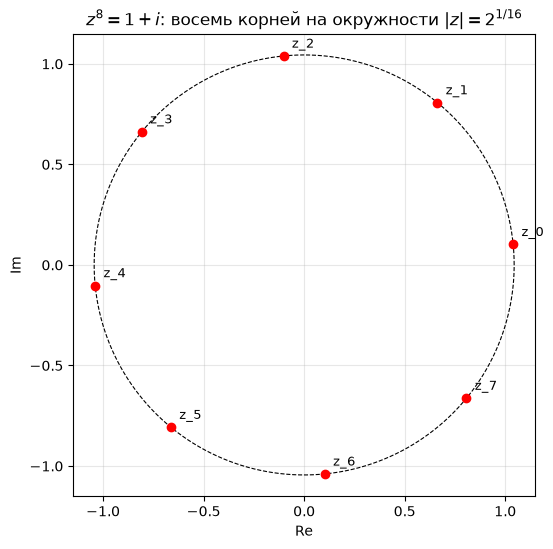

In [3]:
n = 8
radius = 2.0 ** (1 / 16)          # точно: 2^(1/16)
z2 = [radius * np.exp(1j * (np.pi / 4 + 2 * np.pi * k) / n)
      for k in range(n)]

print("z_k = 2^(1/16) * exp(i*pi*(1/32 + k/4)), k = 0..7")
for k, zk in enumerate(z2):
    print(f"z_{k} = {zk:.6f}")

fig, ax = plt.subplots(figsize=(6, 6))
t = np.linspace(0, 2 * np.pi, 400)
ax.plot(radius * np.cos(t), radius * np.sin(t), 'k--', lw=0.8)
ax.plot([z.real for z in z2], [z.imag for z in z2], 'ro')
for k, zk in enumerate(z2):
    ax.annotate(f"z_{k}", (zk.real, zk.imag), textcoords='offset points',
                xytext=(6, 6), fontsize=9)
ax.set_title(r'$z^8 = 1+i$: восемь корней на окружности $|z| = 2^{1/16}$')
ax.set_xlabel('Re'); ax.set_ylabel('Im')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.show()

## 2.3. Вычисление корней (над $\mathbb{C}$) и изображение

Корни степени $n$ из $w = |w|e^{i\varphi}$:
$\sqrt[n]{w} = |w|^{1/n} e^{i(\varphi + 2\pi k)/n}$, $k = 0, \ldots, n-1$.

a) $\sqrt[8]{1}$; б) $\sqrt[4]{-\dfrac{18}{1 + i\sqrt3}}$;
в) $\sqrt[3]{\dfrac{1 - 5i}{1 + i}} - \dfrac{\sqrt[5]{1 + 2i}}{2 - i} + 1$;
г) $\sqrt[9]{1 - i}$.

In [4]:
def all_roots(w, n):
    # все n корней степени n из комплексного числа w
    return [abs(w) ** (1 / n) * np.exp(1j * (np.angle(w) + 2 * np.pi * k) / n)
            for k in range(n)]


print("a) 8 корней из 1:")
ra = all_roots(1 + 0j, 8)
for k, r in enumerate(ra):
    print(f"   {r:.6f}   (= e^(i*pi*{k}/4))")

wb = -18 / (1 + 1j * np.sqrt(3))
print(f"б) подкоренное: -18/(1+i*sqrt3) = {wb} = 9*e^(2i*pi/3)")
rb = all_roots(wb, 4)
for k, r in enumerate(rb):
    print(f"   {r:.6f}   (= sqrt(3)*e^(i*pi*(1/6 + {k}/2)))")

a) 8 корней из 1:
   1.000000+0.000000j   (= e^(i*pi*0/4))
   0.707107+0.707107j   (= e^(i*pi*1/4))
   0.000000+1.000000j   (= e^(i*pi*2/4))
   -0.707107+0.707107j   (= e^(i*pi*3/4))
   -1.000000+0.000000j   (= e^(i*pi*4/4))
   -0.707107-0.707107j   (= e^(i*pi*5/4))
   -0.000000-1.000000j   (= e^(i*pi*6/4))
   0.707107-0.707107j   (= e^(i*pi*7/4))
б) подкоренное: -18/(1+i*sqrt3) = (-4.500000000000001+7.794228634059948j) = 9*e^(2i*pi/3)
   1.500000+0.866025j   (= sqrt(3)*e^(i*pi*(1/6 + 0/2)))
   -0.866025+1.500000j   (= sqrt(3)*e^(i*pi*(1/6 + 1/2)))
   -1.500000-0.866025j   (= sqrt(3)*e^(i*pi*(1/6 + 2/2)))
   0.866025-1.500000j   (= sqrt(3)*e^(i*pi*(1/6 + 3/2)))


в) (1-5i)/(1+i) = -2 - 3*I , (1+2i)/(2-i) = I
   три кубических корня из -2-3i:
   1.153228-1.010643j
   0.298628+1.504046j
   -1.451857-0.493404j
   пять корней 5-й степени из i:
   0.951057+0.309017j
   0.000000+1.000000j
   -0.951057+0.309017j
   -0.587785-0.809017j
   0.587785-0.809017j
   главное значение: 1.202172-1.319660j


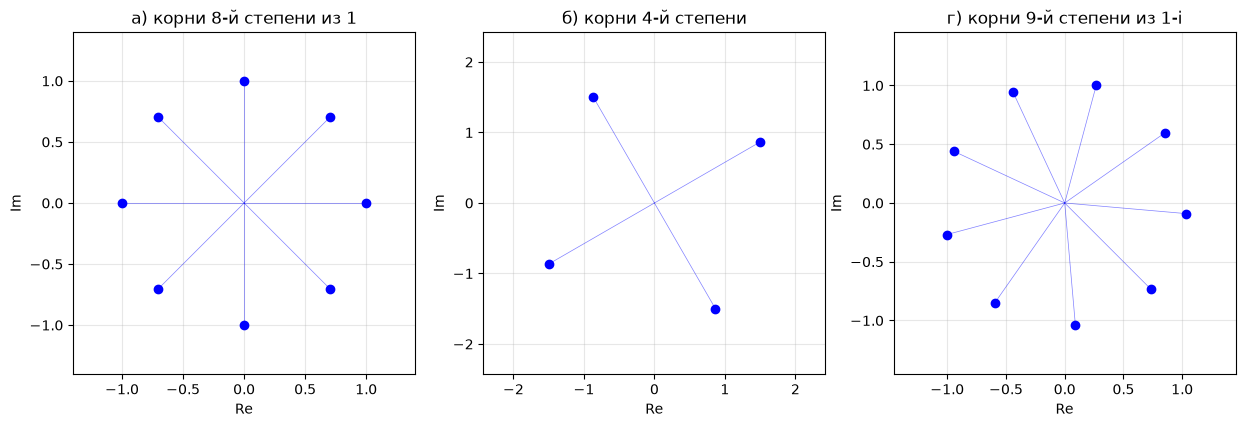

In [5]:
print("в) (1-5i)/(1+i) =", sp.simplify((1 - 5 * sp.I) / (1 + sp.I)),
      ", (1+2i)/(2-i) =", sp.simplify((1 + 2 * sp.I) / (2 - sp.I)))
rc = all_roots(complex((1 - 5j) / (1 + 1j)), 3)
rd = all_roots(1 - 1j, 9)
print("   три кубических корня из -2-3i:")
for r in rc:
    print(f"   {r:.6f}")
print("   пять корней 5-й степени из i:")
for r in all_roots(1j, 5):
    print(f"   {r:.6f}")

# главное значение всего выражения
principal = rc[0] - all_roots(1j, 5)[0] + 1
print(f"   главное значение: {principal:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, roots, name in [(axes[0], ra, 'a) корни 8-й степени из 1'),
                        (axes[1], rb, 'б) корни 4-й степени'),
                        (axes[2], rd, 'г) корни 9-й степени из 1-i')]:
    ax.plot([r.real for r in roots], [r.imag for r in roots], 'bo', ms=6)
    for r in roots:
        ax.plot([0, r.real], [0, r.imag], 'b-', lw=0.5, alpha=0.5)
    ax.set_title(name); ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    m = 1.4 * max(abs(r) for r in roots)
    ax.set_xlim(-m, m); ax.set_ylim(-m, m)
plt.show()

## 2.4. Множества точек на комплексной плоскости

**a)** $|z - i| + |z + i| < 4$; **б)** $\operatorname{Re}\bigl(z(1 - i)\bigr) < \sqrt2$;
**в)** $|z + 1| = |z + i| = |z - i|$;
**г)** $0 < \arg\dfrac{i - z}{z + i} < \dfrac{\pi}{2}$;
**д)** $-\dfrac{2\pi}{3} \le \arg\dfrac{2 - iz}{z + 3i} \le -\dfrac{5\pi}{6}$;
**е)** $-\dfrac{2\pi}{3} \le \arg\dfrac{3 - z}{z + i} \le -\dfrac{\pi}{3}$.

**Идея:** условие $\arg \dfrac{z - a}{z - b} = \text{const}$ задаёт дугу окружности,
проходящей через точки $a$ и $b$ (теорема о вписанном угле); неравенства —
соответствующие круговые сегменты. Множества изображаются затенением сетки.

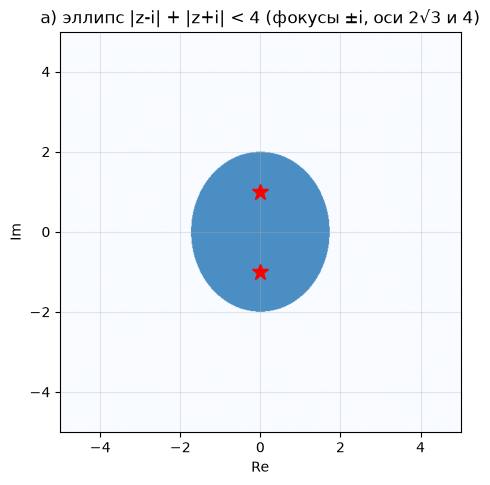

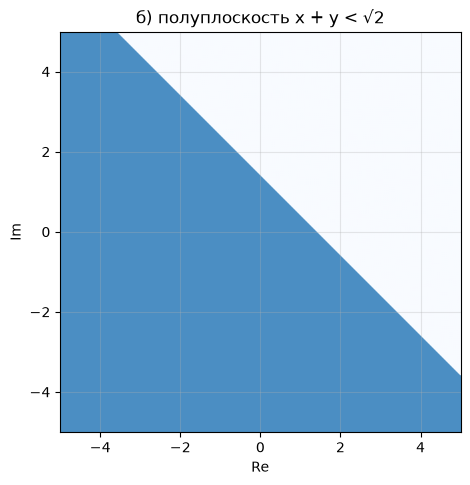

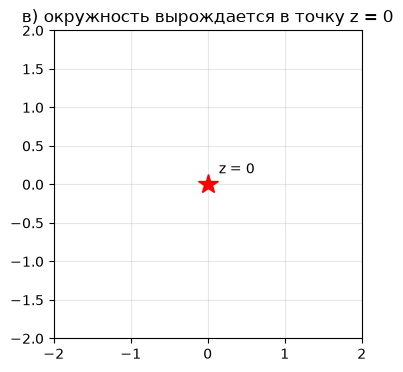

In [6]:
def plot_region(fn, title, points=(), lim=5):
    # затенить область, где fn(x, y) == True
    n = 600
    xs = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(xs, xs)
    Z = X + 1j * Y
    mask = fn(Z)
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.imshow(mask, extent=[-lim, lim, -lim, lim], origin='lower',
              cmap='Blues', alpha=0.85, vmin=0, vmax=1.4)
    for p in points:
        ax.plot(p.real, p.imag, 'r*', ms=12)
    ax.set_title(title)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    plt.show()


# а) эллипс с фокусами +-i: сумма расстояний < 4
plot_region(lambda z: np.abs(z - 1j) + np.abs(z + 1j) < 4,
            'а) эллипс |z-i| + |z+i| < 4 (фокусы ±i, оси 2√3 и 4)',
            points=[1j, -1j])
# б) Re(z(1-i)) = x + y < sqrt(2)
plot_region(lambda z: (z * (1 - 1j)).real < np.sqrt(2),
            'б) полуплоскость x + y < √2')
# в) единственная точка z = 0
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(0, 0, 'r*', ms=15)
ax.annotate('z = 0', (0, 0), textcoords='offset points', xytext=(8, 8))
ax.set_title('в) окружность вырождается в точку z = 0')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.show()

Пояснения:

**а)** сумма расстояний до фокусов $\pm i$ постоянна ($= 4$) — эллипс
с полуосями $2$ (по $y$) и $\sqrt3$ (по $x$): $\dfrac{x^2}{3} + \dfrac{y^2}{4} = 1$;

**б)** $z(1 - i) = (x + y) + i(y - x)$, условие $x + y < \sqrt2$ — полуплоскость;

**в)** из $|z + i| = |z - i|$ следует $y = 0$; из $|z + 1| = |z - i|$ при $y = 0$
следует $x = 0$ — единственная точка $z = 0$ (центр окружности,
проходящей через $-1, -i, i$).

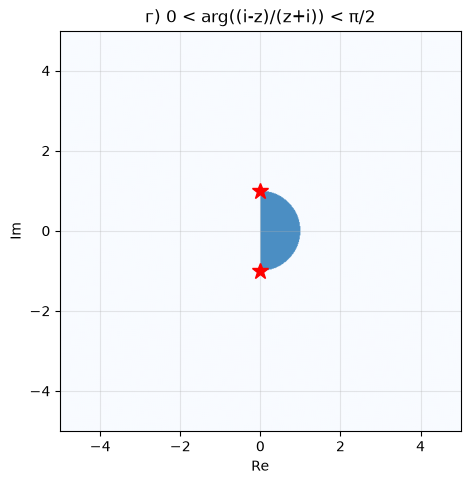

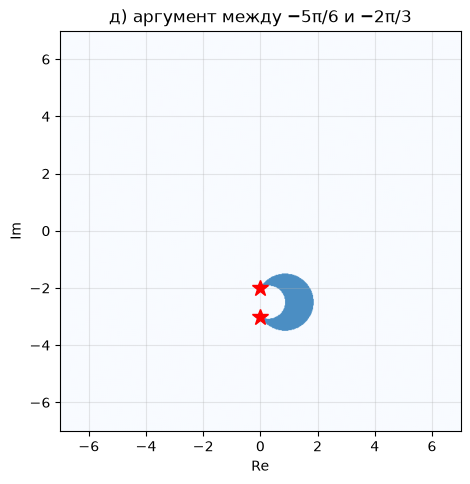

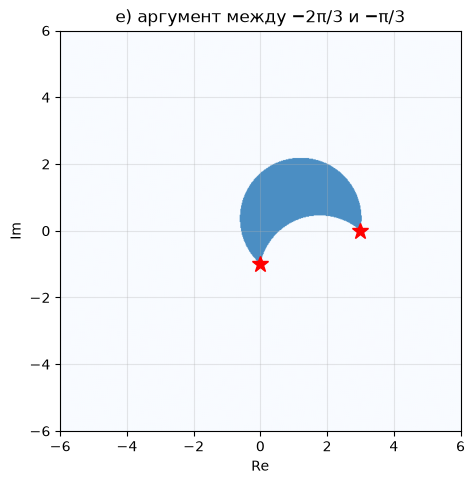

In [7]:
# г) дуги окружностей через точки i (нуль) и -i (полюс)
plot_region(lambda z: (0 < np.angle((1j - z) / (z + 1j)))
            & (np.angle((1j - z) / (z + 1j)) < np.pi / 2),
            'г) 0 < arg((i-z)/(z+i)) < π/2', points=[1j, -1j])
# д) дуги через -2i (нуль) и -3i (полюс); в условии пределы −5π/6 и −2π/3
plot_region(lambda z: (-5 * np.pi / 6 <= np.angle((2 - 1j * z) / (z + 3j)))
            & (np.angle((2 - 1j * z) / (z + 3j)) <= -2 * np.pi / 3),
            'д) аргумент между −5π/6 и −2π/3', points=[-2j, -3j], lim=7)
# е) дуги через 3 (нуль) и -i (полюс)
plot_region(lambda z: (-2 * np.pi / 3 <= np.angle((3 - z) / (z + 1j)))
            & (np.angle((3 - z) / (z + 1j)) <= -np.pi / 3),
            'е) аргумент между −2π/3 и −π/3', points=[3 + 0j, -1j], lim=6)

Во всех трёх случаях линии $\arg = \text{const}$ — дуги окружностей,
проходящие через точку нуля и полюса дроби (отмечены звёздочками):
г) через $i$ и $-i$; д) через $-2i$ и $-3i$; е) через $3$ и $-i$.

## 2.5*. Уравнение окружности в комплексной форме

Пусть $A, C$ — действительные, $B$ — комплексные постоянные,
$AC < |B|^2$. Показать, что при $A > 0$ уравнение

$$A|z|^2 + Bz + \overline{B}\,\overline{z} + C = 0$$

— уравнение окружности, и найти центр и радиус.

**Решение.** Пусть $B = b_1 + i b_2$, $z = x + iy$. Тогда
$Bz + \overline{Bz} = 2\operatorname{Re}(Bz) = 2(b_1 x - b_2 y)$, и уравнение
принимает вид

$$A(x^2 + y^2) + 2b_1 x - 2b_2 y + C = 0.$$

Выделяя полные квадраты (и деля на $A > 0$):

$$\Bigl(x + \frac{b_1}{A}\Bigr)^2 + \Bigl(y - \frac{b_2}{A}\Bigr)^2
= \frac{b_1^2 + b_2^2 - AC}{A^2} = \frac{|B|^2 - AC}{A^2} > 0.$$

Это окружность с центром $\bigl(-\frac{b_1}{A}, \frac{b_2}{A}\bigr)$,
т. е. $z_0 = -\dfrac{\overline{B}}{A}$, и радиусом
$R = \dfrac{\sqrt{|B|^2 - AC}}{A}$. $\blacksquare$

In [8]:
# проверка: берём случайные A, C, B, находим 3 точки исходного
# уравнения и убеждаемся, что они лежат на найденной окружности
A, C = 2.0, 1.0
B = 1.0 + 2.0j


def F(z):
    return A * abs(z)**2 + 2 * (B * z).real + C


z0 = -B.conjugate() / A
R = math.sqrt(abs(B)**2 - A * C) / A
print(f"центр z0 = {z0}, радиус R = {R:.6f}")

# решаем F = 0 при трёх фиксированных x, проверяем |z - z0| = R
# x должны попадать внутрь окружности: |x + 0.5| <= 0.866
x_vals = [-0.5, 0.0, 0.3]
yy = sp.symbols('yy', real=True)
for xv in x_vals:
    sols = sp.solve(sp.Eq(A * (xv**2 + yy**2)
                          + 2 * sp.re(B * (xv + sp.I * yy)) + C, 0), yy)
    for s in sols:
        z = xv + 1j * float(sp.re(s))
        print(f"точка ({xv}, {float(sp.re(s)):.4f}): "
              f"F = {F(z):.2e}, |z - z0| - R = {abs(z - z0) - R:.2e}")

центр z0 = (-0.5+1j), радиус R = 0.866025
точка (-0.5, 0.1340): F = 0.00e+00, |z - z0| - R = -2.22e-16
точка (-0.5, 1.8660): F = 1.78e-15, |z - z0| - R = -2.22e-16
точка (0.0, 0.2929): F = 0.00e+00, |z - z0| - R = -2.22e-16
точка (0.0, 1.7071): F = 0.00e+00, |z - z0| - R = -2.22e-16
точка (0.3, 0.6683): F = 2.22e-16, |z - z0| - R = -1.11e-16
точка (0.3, 1.3317): F = 4.44e-16, |z - z0| - R = -1.11e-16


## 2.6. Все корни многочлена

$$p(x) = x^{11} + x^{10} + x^8 - 2x^7 - x^5 + x^4 + 2x^2 + 2x + 2.$$

Найти все 11 корней; указать 1) сумму модулей корней; 2) максимальную
действительную часть корня.

In [9]:
coefs = [1, 1, 0, 1, -2, 0, -1, 1, 0, 2, 2, 2]
roots = np.roots(coefs)
print("число корней:", len(roots))
print("макс. остаток p(z_k):",
      max(abs(np.polyval(coefs, r)) for r in roots))
print(f"1) сумма модулей: {np.sum(np.abs(roots)):.6f}")
k = int(np.argmax(roots.real))
print(f"2) макс. действительная часть: {roots[k].real:.6f} "
      f"(корень {roots[k]:.6f})")

число корней: 11
макс. остаток p(z_k): 1.3589129821411916e-13
1) сумма модулей: 11.973384
2) макс. действительная часть: 1.080602 (корень 1.080602+0.323893j)


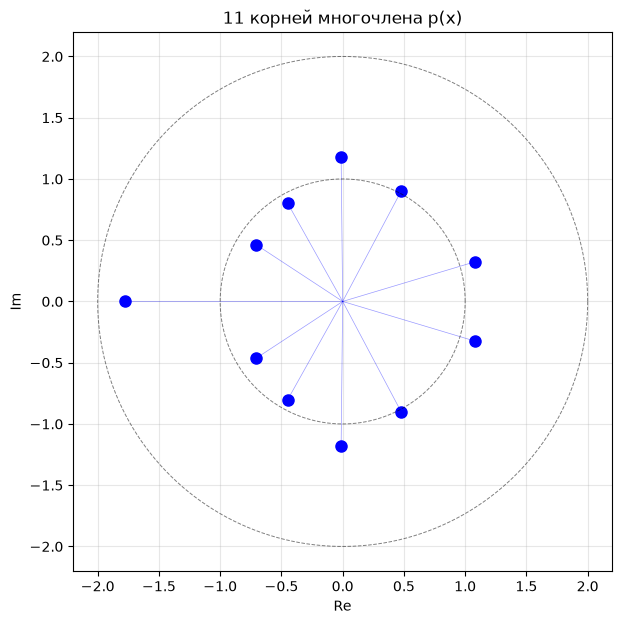

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(roots.real, roots.imag, 'bo', ms=8)
for r in roots:
    ax.plot([0, r.real], [0, r.imag], 'b-', lw=0.5, alpha=0.4)
t = np.linspace(0, 2 * np.pi, 400)
for rad in (1.0, 2.0):
    ax.plot(rad * np.cos(t), rad * np.sin(t), 'k--', lw=0.7, alpha=0.5)
ax.set_title('11 корней многочлена p(x)')
ax.set_xlabel('Re'); ax.set_ylabel('Im')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.show()

## 2.7. Обобщение биномиальных коэффициентов

$C^k_n = \dfrac{n!}{k!(n-k)!}$, $n! = \Gamma(n+1)$. Для $z, w \in \mathbb{C}$:

$$C^w_z = \frac{\Gamma(z + 1)}{\Gamma(w + 1)\,\Gamma(z - w + 1)}.$$

In [11]:
z, w = 1 + 1j, 1 - 1j
C = gamma(z + 1) / (gamma(w + 1) * gamma(z - w + 1))
print(f"а) C^(1-i)_(1+i) = {C:.6f}   (ответ: 4.36745 + 4.85163i)")
print(f"б) Arg C = {np.angle(C):.6f} рад = {np.degrees(np.angle(C)):.4f}°"
      f"   (ответ: 0.837869 / 48.0064°)")

а) C^(1-i)_(1+i) = 4.367449+4.851630j   (ответ: 4.36745 + 4.85163i)
б) Arg C = 0.837869 рад = 48.0064°   (ответ: 0.837869 / 48.0064°)


в) Линии уровня аргумента обобщённого биномиального коэффициента.
Формула в условии читается неоднозначно; изображён портрет аргумента
функции $f(z) = \dfrac{1}{C^z_1} = \Gamma(z+1)\,\Gamma(2-z)
= \dfrac{\pi z (1 - z)}{\sin \pi z}$ (полюсы — в ненулевых целых точках,
что и видно на картинке). Цвет — значение $\arg f$, чёрные пунктирные
линии — линии уровня $\arg f = \text{const}$.

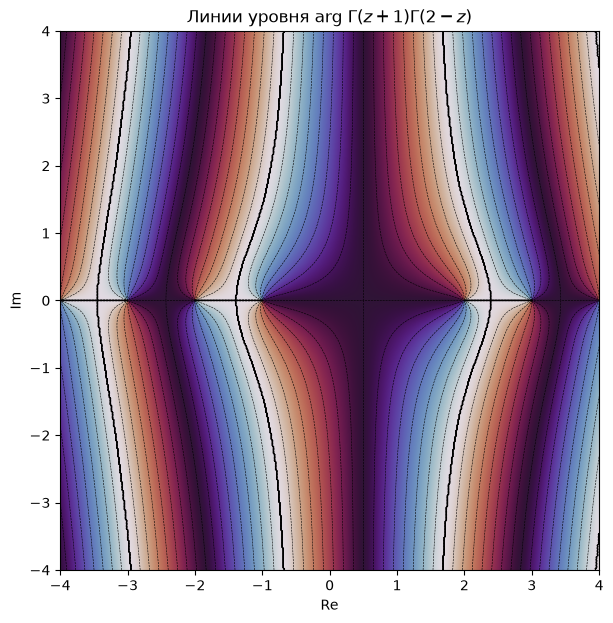

In [12]:
n = 500
xs = np.linspace(-4, 4, n)
X, Y = np.meshgrid(xs, xs)
Z = X + 1j * Y
with np.errstate(all='ignore'):
    F = gamma(Z + 1) * gamma(2 - Z)
phase = np.angle(F)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(phase, extent=[-4, 4, -4, 4], origin='lower', cmap='twilight')
ax.contour(X, Y, phase, levels=np.linspace(-np.pi, np.pi, 17),
           colors='k', linewidths=0.4, linestyles='dashed')
ax.set_title(r'Линии уровня $\arg\, \Gamma(z+1)\Gamma(2-z)$')
ax.set_xlabel('Re'); ax.set_ylabel('Im')
plt.show()

## 2.8. Корень степени 14 из 1

Пусть $\lambda$ — корень степени 14 из 1 с $\operatorname{Im}\lambda > 0$
и максимальной действительной частью среди таких. Корни:
$\lambda_k = e^{2\pi i k/14}$, $k = 1, \ldots, 6$ (условие $\operatorname{Im} > 0$);
максимум $\cos(2\pi k/14)$ достигается при $k = 1$: $\lambda = e^{i\pi/7}$.

Дано $I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$,
$A = \begin{pmatrix} 7 & 5 \\ 6 & 2 \end{pmatrix}$. Найти $\det(A + \lambda I)$.

In [13]:
cands = [np.exp(2j * np.pi * k / 14) for k in range(1, 7)]
lam = max(cands, key=lambda c: c.real)
print(f"lambda = {lam:.6f} = cos(pi/7) + i sin(pi/7)")

A = np.array([[7.0, 5.0], [6.0, 2.0]])
d = np.linalg.det(A + lam * np.eye(2))
print(f"det(A + lambda I) = lambda^2 + 9 lambda - 16 = {d:.6f}")
print(f"1) действительная часть: {d.real:.6f}")
print(f"2) мнимая часть:          {d.imag:.6f}")

lambda = 0.900969+0.433884j = cos(pi/7) + i sin(pi/7)
det(A + lambda I) = lambda^2 + 9 lambda - 16 = -7.267790+4.686785j
1) действительная часть: -7.267790
2) мнимая часть:          4.686785


## 2.9*. Множества Жюлиа

**a), б)** Множество Жюлиа $J(f)$ — граница множества начальных точек,
орбиты которых сходятся под итерациями рациональной функции $f$;
для $f_c(z) = z^2 + c$ оно связно тогда и только тогда, когда $c$ принадлежит
мандельбротову множеству. См. Wikipedia: *Julia set*.

**в)** Множества Жюлиа для $f_c(z) = z^2 + c$ при $c = -0{,}1 + 0{,}65i$ и
$c = 0{,}28 + 0{,}009i$ (векторизованный escape-time алгоритм: точка $z$
«улетает», если $|z_k| > 2$ для некоторой итерации $z_k = z_{k-1}^2 + c$).

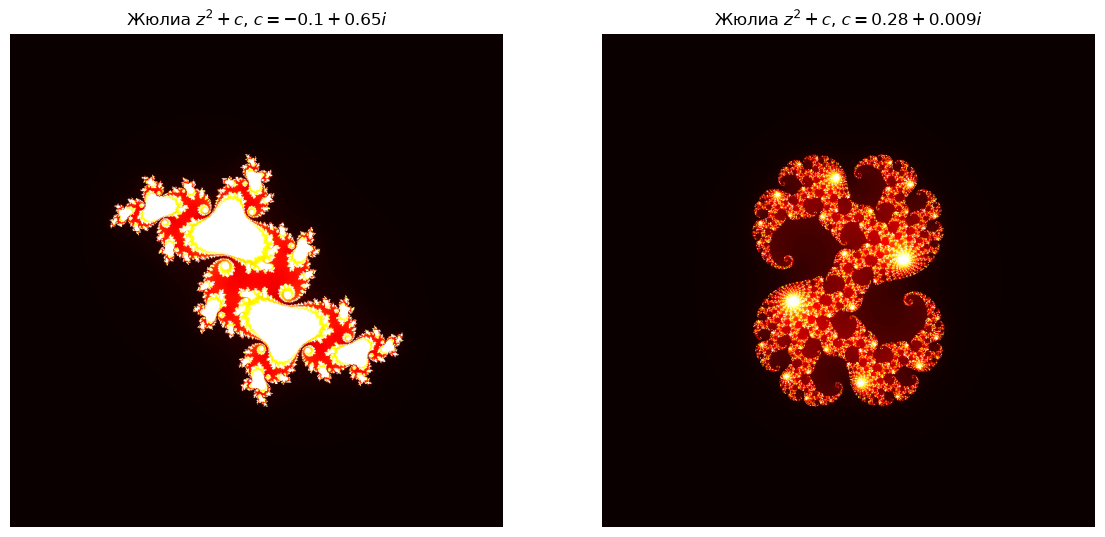

In [14]:
def julia_quadratic(c, size=700, max_iter=200, win=2.1):
    x = np.linspace(-win, win, size)
    X, Y = np.meshgrid(x, x)
    Z = X + 1j * Y
    M = np.full(Z.shape, max_iter)
    alive = np.ones(Z.shape, dtype=bool)
    for i in range(max_iter):
        Z[alive] = Z[alive] ** 2 + c
        escaped = np.abs(Z) > 2
        M[escaped & alive] = i
        alive &= ~escaped
    return M


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, c in zip(axes, (-0.1 + 0.65j, 0.28 + 0.009j)):
    M = julia_quadratic(c)
    ax.imshow(M, extent=[-2.1, 2.1, -2.1, 2.1], origin='lower',
              cmap='hot')
    ax.set_title(f'Жюлиа $z^2 + c$, $c = {c.real} {c.imag:+}i$')
    ax.set_aspect('equal'); ax.axis('off')
plt.show()

**г)** Множества Жюлиа для рациональных функций
$f(z) = \dfrac{iz^5 - 1}{z^5 - i}$ и $f(z) = \dfrac{z^2 + i}{1 - z^2}$.

Для рациональных функций бесконечность не притягивает орбиты так же,
как для многочленов: точка считается улетевшей, если $|z_k|$ превысило
большой радиус $R$, либо знаменатель обратился в ноль (следующая итерация
даёт $\infty$).

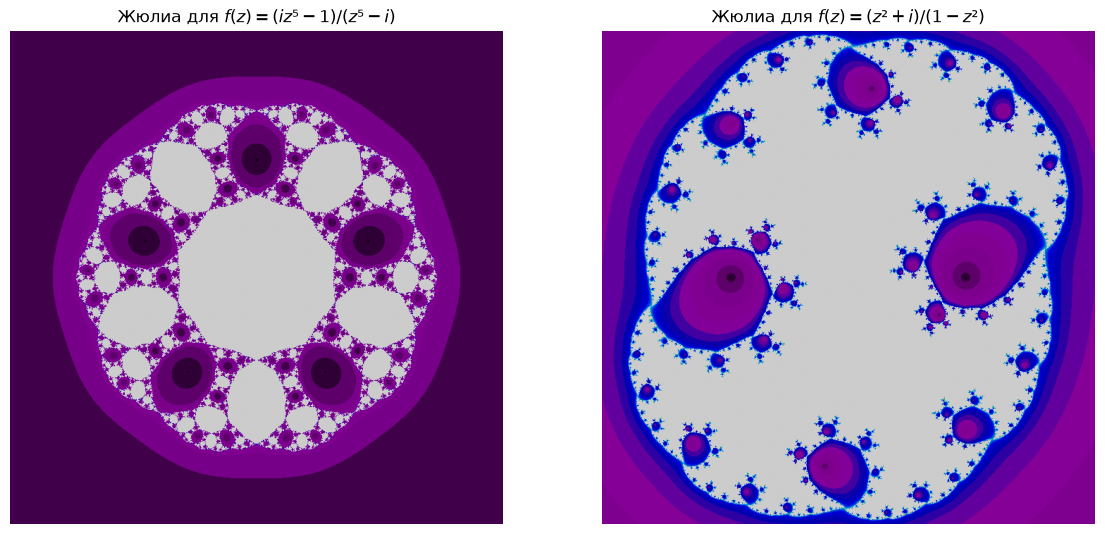

In [15]:
def julia_rational(num, den, size=700, max_iter=100, win=2.1):
    x = np.linspace(-win, win, size)
    X, Y = np.meshgrid(x, x)
    Z = X + 1j * Y
    M = np.full(Z.shape, max_iter)
    alive = np.ones(Z.shape, dtype=bool)
    for i in range(max_iter):
        d = den(Z)
        pole = np.abs(d) < 1e-13
        with np.errstate(all='ignore'):
            Zn = np.where(pole, 1e12 + 0j, num(Z) / d)
        Zn = np.where(np.isnan(Zn), 1e12 + 0j, Zn)
        Z = np.where(alive, Zn, Z)
        escaped = np.abs(Z) > 1e8
        M[escaped & alive] = i
        alive &= ~escaped
    return M


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
cases = [(lambda z: 1j * z**5 - 1, lambda z: z**5 - 1j, '(iz⁵−1)/(z⁵−i)'),
         (lambda z: z**2 + 1j, lambda z: 1 - z**2, '(z²+i)/(1−z²)')]
for ax, (num, den, name) in zip(axes, cases):
    M = julia_rational(num, den)
    ax.imshow(M, extent=[-2.1, 2.1, -2.1, 2.1], origin='lower',
              cmap='nipy_spectral')
    ax.set_title(f'Жюлиа для $f(z) = {name}$')
    ax.set_aspect('equal'); ax.axis('off')
plt.show()

## 2.10*. Кривые на сфере Римана

Стереографическая проекция: точка $z = x + iy$ комплексной плоскости
отображается на единичную сферу с северным полюсом $N = (0,0,1)$ по
формулам

$$x_s = \frac{2x}{1 + r^2}, \qquad y_s = \frac{2y}{1 + r^2},
\qquad z_s = \frac{r^2 - 1}{1 + r^2}, \qquad r^2 = x^2 + y^2.$$

Прямые и окружности плоскости переходят в окружности на сфере
(прямые — в окружности, проходящие через $N$); парабола и гипербола
переходят в замкнутые кривые через $N$.

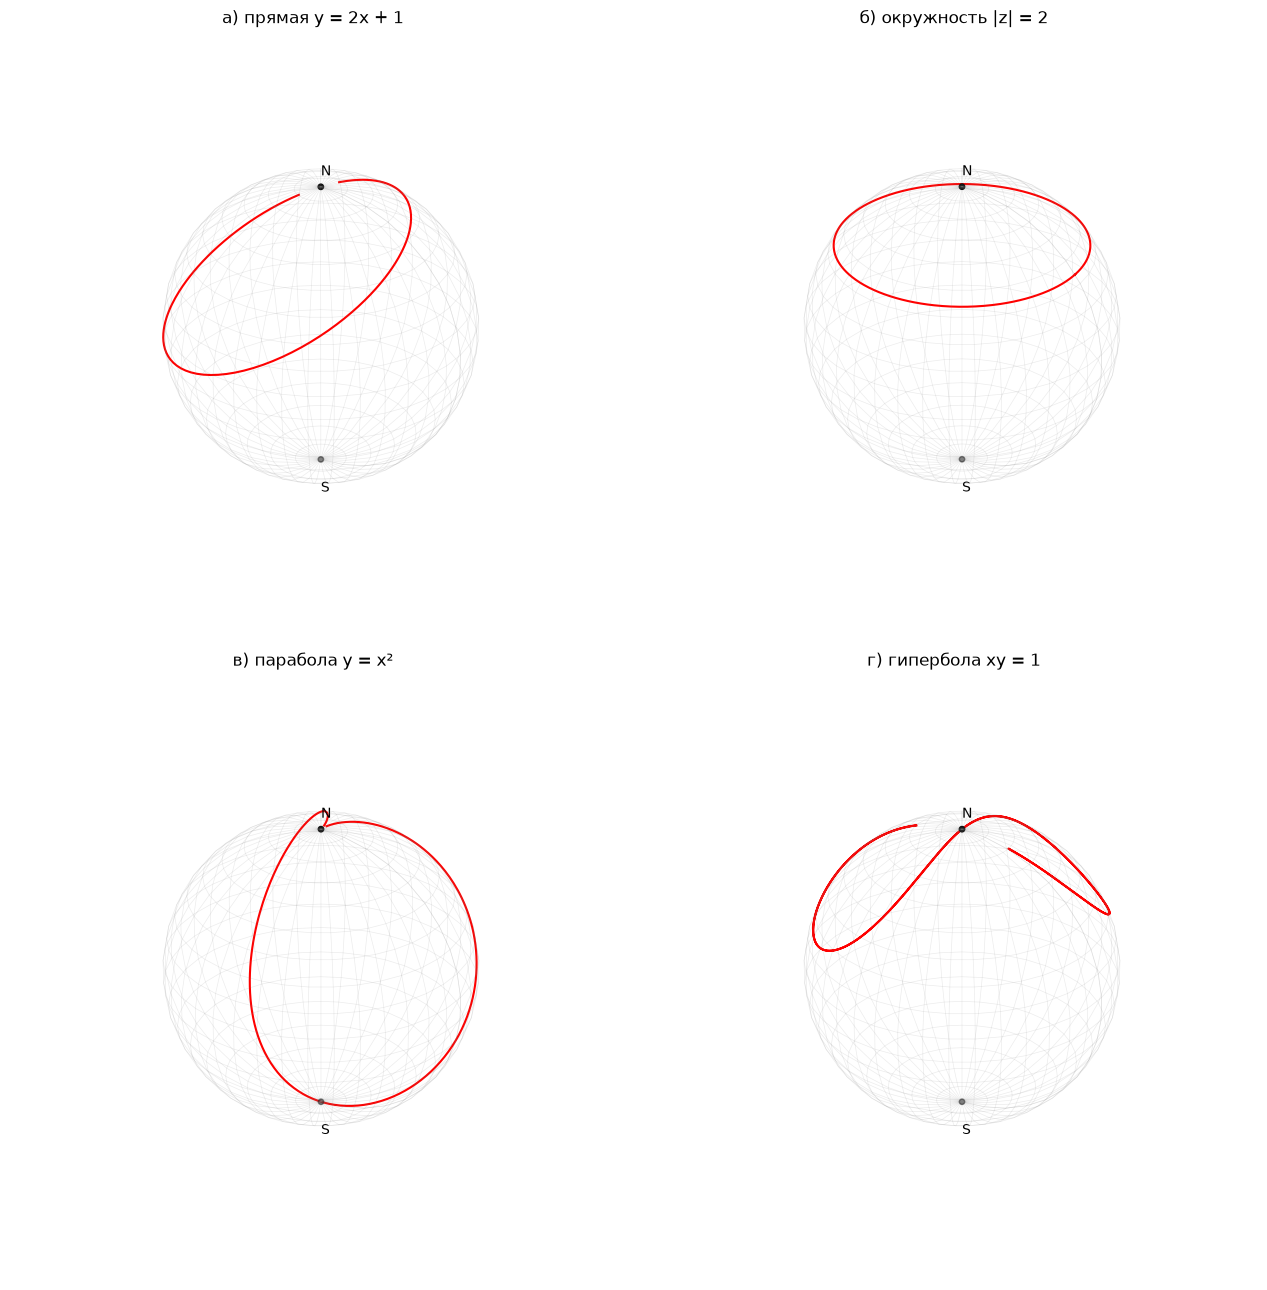

In [16]:
def stereo(z):
    # стереографическое поднятие комплексной кривой на сферу
    x, y = z.real, z.imag
    r2 = x**2 + y**2
    return np.array([2 * x / (1 + r2), 2 * y / (1 + r2),
                     (r2 - 1) / (1 + r2)])


def sphere_wire(ax):
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.15, lw=0.5)
    ax.scatter([0, 0], [0, 0], [1, -1], color='k', s=15)
    ax.text(0, 0, 1.08, 'N'); ax.text(0, 0, -1.25, 'S')
    ax.set_box_aspect((1, 1, 1))
    ax.axis('off')


t = np.linspace(-6, 6, 600)
curves = [
    (t + (2 * t + 1) * 1j, 'a) прямая y = 2x + 1'),
    (2 * np.exp(1j * np.linspace(0, 2 * np.pi, 600)), 'б) окружность |z| = 2'),
    (t + t**2 * 1j, 'в) парабола y = x²'),
    (np.concatenate([t + 1j / t, -(t + 1j / t)]), 'г) гипербола xy = 1'),
]
fig = plt.figure(figsize=(13, 13))
for k, (z, name) in enumerate(curves, 1):
    ax = fig.add_subplot(2, 2, k, projection='3d')
    sphere_wire(ax)
    s = stereo(z)
    ax.plot(s[0], s[1], s[2], 'r-', lw=1.5)
    ax.set_title(name)
plt.tight_layout()
plt.show()

Второе задание 2.10 (в оригинале нумерация повторяется):
**логарифмическая спираль** $r = a e^{b\varphi}$. При $\varphi \to +\infty$
спираль уходит в бесконечность плоскости, т. е. на сфере стягивается
к северному полюсу $N$; при $\varphi \to -\infty$ — к южному полюсу.

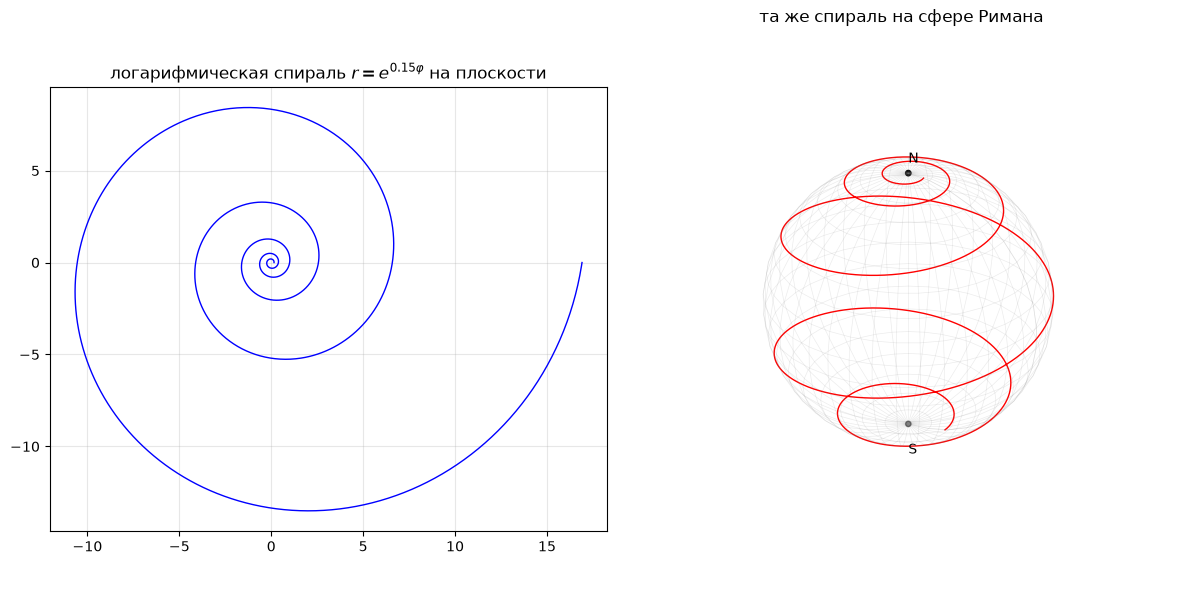

In [17]:
phi = np.linspace(-4 * np.pi, 6 * np.pi, 3000)
a, b = 1.0, 0.15
z = a * np.exp(b * phi) * np.exp(1j * phi)

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(z.real, z.imag, 'b-', lw=1)
ax1.set_title('логарифмическая спираль $r = e^{0.15\\varphi}$ на плоскости')
ax1.set_aspect('equal'); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sphere_wire(ax2)
s = stereo(z)
ax2.plot(s[0], s[1], s[2], 'r-', lw=1)
ax2.set_title('та же спираль на сфере Римана')
plt.tight_layout()
plt.show()

---

Все задачи листка решены: формы комплексных чисел, корни и области на
плоскости, уравнение окружности, корни многочлена, гамма-биномиальные
коэффициенты, определитель с корнем из 1, множества Жюлиа и кривые на
сфере Римана.